# FT-Transformer Baseline

Supervised baseline implementing FT-Transformer (Gorishniy et al. 2021) in pure PyTorch — no extra dependencies beyond what the SSL pipeline notebook already uses.

**Text handling**: `bert-base-uncased` embeddings (frozen, mean-pooled last hidden state) are pre-computed for all 4,914 rows, reduced to 128 dims via PCA fit on the full unlabelled pool, then concatenated with the 36 NBI numeric features. FT-T receives 164 numeric + 54 categorical features.

**Two operating modes** controlled by `DO_PRETRAIN` in Section 4:
- `DO_PRETRAIN=False` — supervised-only; the full model is trained from scratch on each fold's labeled split.
- `DO_PRETRAIN=True` — masked-feature pretraining on all 4,914 rows first, then the encoder is frozen and only the SCCI heads + last transformer layer are fine-tuned.

Both modes use the same 5-fold stratified splits, CQR calibration, OOF evaluation, and CAP curve as the SSL pipeline notebook.

# 1. Model Definition

In [1]:
import torch
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def pinball_loss(y, q, alpha):
    r = y - q
    return torch.mean(torch.where(r >= 0, alpha * r, (alpha - 1) * r))


class FeatureTokenizer(nn.Module):
    """
    FT-Transformer feature tokenizer (Gorishniy et al. 2021).
    Numeric: each feature i gets its own linear map  token_i = x_i * W_i + b_i
             where W_i, b_i ∈ R^d_model  (learned per-feature scalings).
    Categorical: each feature gets its own nn.Embedding table.
    Output: (B, N_num + N_cat, d_model)
    """

    def __init__(self, n_num: int, cat_vocab_sizes: list, d_model: int):
        super().__init__()
        self.n_num = n_num
        self.n_cat = len(cat_vocab_sizes)
        self.num_W = nn.Parameter(torch.empty(n_num, d_model))
        self.num_b = nn.Parameter(torch.empty(n_num, d_model))
        nn.init.kaiming_uniform_(self.num_W, a=math.sqrt(5))
        nn.init.zeros_(self.num_b)
        self.cat_embs = nn.ModuleList(
            [nn.Embedding(vsz, d_model) for vsz in cat_vocab_sizes]
        )

    def forward(self, x_num, x_cat):
        tokens = [x_num[..., None] * self.num_W[None] + self.num_b[None]]
        tokens += [self.cat_embs[i](x_cat[:, i]).unsqueeze(1) for i in range(self.n_cat)]
        return torch.cat(tokens, dim=1)   # (B, N_num+N_cat, d_model)


class FTTransformerSCCI(nn.Module):
    """
    FT-Transformer encoder + two SCCI heads + optional masked-feature pretraining.

    n_num : total numeric features (NBI 36 + text PCA 128 = 164)
    n_nbi : NBI-only numeric features to reconstruct during pretraining (36).
            Text PCA features are always visible — masking them has no semantic value
            since they are derived from a frozen external encoder, not raw measurements.

    mode='regress'  — supervised fine-tuning (CLS → two SCCI heads)
    mode='pretrain' — masked feature reconstruction (NBI numeric + categorical only)
    """

    def __init__(
        self,
        n_num:           int,
        cat_vocab_sizes: list,
        d_model:         int   = 128,
        nhead:           int   = 8,
        n_layers:        int   = 4,
        ffn_factor:      float = 4.0,
        dropout:         float = 0.1,
        n_nbi:           int   = None,
    ):
        super().__init__()
        self.n_num = n_num
        self.n_nbi = n_nbi if n_nbi is not None else n_num
        self.n_cat = len(cat_vocab_sizes)

        self.tokenizer = FeatureTokenizer(n_num, cat_vocab_sizes, d_model)
        self.cls_token = nn.Parameter(torch.empty(1, 1, d_model))
        nn.init.normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=int(d_model * ffn_factor),
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Supervised heads (regress mode)
        self.scci_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Dropout(0.3),
            nn.GELU(),
            nn.Linear(d_model // 2, 2),
        )
        self.scci_point_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Dropout(0.3),
            nn.GELU(),
            nn.Linear(d_model // 2, 1),
        )

        # Reconstruction heads (pretrain mode only — frozen / unused during fine-tuning)
        self.num_recon = nn.ModuleList([nn.Linear(d_model, 1) for _ in range(self.n_nbi)])
        self.cat_recon = nn.ModuleList([nn.Linear(d_model, vsz - 1) for vsz in cat_vocab_sizes])

    def _encode(self, x_num, x_cat):
        B      = x_num.size(0)
        tokens = self.tokenizer(x_num, x_cat)
        cls    = self.cls_token.expand(B, -1, -1)
        return self.transformer(torch.cat([cls, tokens], dim=1))

    def forward(
        self,
        x_num,
        x_cat,
        y_scci               = None,
        num_mask             = None,
        num_targets          = None,
        cat_mask             = None,
        cat_targets          = None,
        mode:                str   = 'regress',
        alpha:               float = 0.10,
        scci_pinball_weight: float = 1.0,
        scci_point_weight:   float = 1.0,
    ):
        if mode == 'regress':
            h       = self._encode(x_num, x_cat)
            cls_out = h[:, 0]

            scci_raw   = self.scci_head(cls_out)
            q_lo       = scci_raw[:, 0]
            q_hi       = q_lo + F.softplus(scci_raw[:, 1])
            scci_point = self.scci_point_head(cls_out).squeeze(-1)

            loss = None
            if y_scci is not None:
                valid = ~torch.isnan(y_scci)
                total = torch.tensor(0.0, device=x_num.device)
                if valid.sum() > 0:
                    y_v = y_scci[valid]
                    pb  = (pinball_loss(y_v, q_lo[valid], alpha / 2)
                           + pinball_loss(y_v, q_hi[valid], 1.0 - alpha / 2))
                    total = total + scci_pinball_weight * pb
                    total = total + scci_point_weight * F.mse_loss(scci_point[valid], y_v)
                loss = total

            return {
                'scci_direct': {'q_lo': q_lo, 'q_hi': q_hi},
                'scci_point':  scci_point,
                'loss':        loss,
            }

        elif mode == 'pretrain':
            h          = self._encode(x_num, x_cat)
            total_loss = torch.tensor(0.0, device=x_num.device)

            # Reconstruct masked NBI numeric features
            # Sequence layout: [CLS | num_0..num_{n_num-1} | cat_0..cat_{n_cat-1}]
            # Only reconstruct the first n_nbi positions (original NBI, not text PCA)
            H_num = h[:, 1:1+self.n_nbi, :]
            for i in range(self.n_nbi):
                mask = num_mask[:, i]
                if mask.any():
                    pred = self.num_recon[i](H_num[mask, i]).squeeze(-1)
                    total_loss = total_loss + F.mse_loss(pred, num_targets[mask, i])

            # Reconstruct masked categorical features
            H_cat = h[:, 1+self.n_num:1+self.n_num+self.n_cat, :]
            for i in range(self.n_cat):
                mask = cat_mask[:, i]
                if mask.any():
                    logits = self.cat_recon[i](H_cat[mask, i])
                    tgts   = cat_targets[mask, i].clamp(max=logits.shape[-1]-1)
                    total_loss = total_loss + F.cross_entropy(logits, tgts)

            return {'loss': total_loss}

        else:
            raise ValueError(f"Unknown mode: {mode!r}")

# 2. Data Loading

Identical to the SSL pipeline notebook — same preprocessing, sentinel remap, and labeled-row matching.

In [3]:
import torch
import numpy as np
import pandas as pd
import json
import ast
from pathlib import Path
from collections import defaultdict
from torch.utils.data import TensorDataset

OMIT_IMPUTED = True
SENTINEL     = -999

# ── PATHS ─────────────────────────────────────────────────────────────────────
# Notebook lives in  package/models/
# Data lives in      package/data/
BASE_DIR = Path("../data")

with open(BASE_DIR / "metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

numerical_df   = pd.read_csv(BASE_DIR / "numerical.csv")
categorical_df = pd.read_csv(BASE_DIR / "categorical.csv")
text_df        = pd.read_csv(BASE_DIR / "text.csv")
labeled_raw    = pd.read_csv(BASE_DIR / "labeled_dataset.csv")
if OMIT_IMPUTED:
    labeled_raw = labeled_raw[labeled_raw['is_cd_min_imputed'] == 0]
    print("Excluding imputed SCCI rows (OMIT_IMPUTED=True)")

numerical_df   = numerical_df.set_index("unified_id")
categorical_df = categorical_df.set_index("unified_id")
text_df        = text_df.set_index("unified_id")

shared_ids     = (numerical_df.index
                  .intersection(categorical_df.index)
                  .intersection(text_df.index))
numerical_df   = numerical_df.loc[shared_ids]
categorical_df = categorical_df.loc[shared_ids]
text_df        = text_df.loc[shared_ids]
unified_ids    = shared_ids.tolist()

assert numerical_df.columns.tolist()   == metadata["numerical_columns"]
assert categorical_df.columns.tolist() == metadata["categorical_columns"]

X_num_all  = torch.tensor(numerical_df.values,   dtype=torch.float32)
X_cat_all  = torch.tensor(categorical_df.values, dtype=torch.int64)
token_col  = text_df.columns[0]
if isinstance(text_df[token_col].iloc[0], str):
    text_df[token_col] = text_df[token_col].apply(ast.literal_eval)
X_text_all = torch.tensor(np.vstack(text_df[token_col].values), dtype=torch.long)

print(f"X_num_all  : {X_num_all.shape}")
print(f"X_cat_all  : {X_cat_all.shape}")
print(f"X_text_all : {X_text_all.shape}")

# --- Labeled matching ---
TARGET_COLS = ["CD_MIN_filled", "is_cd_min_imputed"]
labeled_raw = labeled_raw[["STRUCTURE_ID"] + TARGET_COLS].copy()
labeled_raw = labeled_raw.dropna(subset=["STRUCTURE_ID", "CD_MIN_filled"])
labeled_raw["STRUCTURE_ID"] = labeled_raw["STRUCTURE_ID"].astype(str).str.strip()
print(f"\nLabeled rows loaded: {len(labeled_raw)}")

structure_to_positions = defaultdict(list)
for pos, uid in enumerate(unified_ids):
    try:
        sid = str(ast.literal_eval(uid)[0]).strip()
        structure_to_positions[sid].append(pos)
    except Exception:
        continue

matched_positions = []
matched_targets   = []
n_not_found = n_ambiguous = n_matched = 0

for _, row in labeled_raw.iterrows():
    sid       = row["STRUCTURE_ID"]
    positions = structure_to_positions.get(sid, [])
    if len(positions) == 0:   n_not_found  += 1; continue
    if len(positions) >  1:   n_ambiguous  += 1; continue
    matched_positions.append(positions[0])
    matched_targets.append({col: row[col] for col in TARGET_COLS})
    n_matched += 1

print(f"\nMatching summary:")
print(f"  Matched (1-to-1)   : {n_matched}")
print(f"  Not found          : {n_not_found}")
print(f"  Ambiguous (dropped): {n_ambiguous}")

# --- Sentinel remap ---
num_feature_names = metadata["numerical_columns"]
cat_feature_names = metadata["categorical_columns"]

dead_col_indices = {
    i for i, _ in enumerate(cat_feature_names)
    if X_cat_all[:, i].unique().tolist() == [SENTINEL]
}
if dead_col_indices:
    keep              = [i for i in range(len(cat_feature_names)) if i not in dead_col_indices]
    cat_feature_names = [cat_feature_names[i] for i in keep]
    X_cat_all         = X_cat_all[:, keep]
    print(f"\nDropped {len(dead_col_indices)} all-sentinel categorical columns")

sentinel_cat_mask            = (X_cat_all == SENTINEL)
X_cat_all                    = X_cat_all + 1
X_cat_all[sentinel_cat_mask] = 0
sentinel_num_mask            = (X_num_all == SENTINEL)
X_num_all[sentinel_num_mask] = 0.0
print(f"Sentinel remap: cat={sentinel_cat_mask.sum().item():,}  num={sentinel_num_mask.sum().item():,}")

cat_vocab_sizes = [int(X_cat_all[:, i].max().item()) + 2 for i in range(X_cat_all.shape[1])]

# --- Targets ---
labeled_pos_tensor = torch.tensor(matched_positions, dtype=torch.long)
y_scci = torch.tensor(
    [t["CD_MIN_filled"] for t in matched_targets], dtype=torch.float32
)
is_imputed = torch.tensor(
    [bool(t["is_cd_min_imputed"]) for t in matched_targets], dtype=torch.bool
)

print(f"\nnum_feature_names : {len(num_feature_names)}")
print(f"cat_feature_names : {len(cat_feature_names)}")
print(f"cat_vocab_sizes   : min={min(cat_vocab_sizes)}  max={max(cat_vocab_sizes)}")

Excluding imputed SCCI rows (OMIT_IMPUTED=True)
X_num_all  : torch.Size([4914, 36])
X_cat_all  : torch.Size([4914, 59])
X_text_all : torch.Size([4914, 160])

Labeled rows loaded: 377

Matching summary:
  Matched (1-to-1)   : 370
  Not found          : 7
  Ambiguous (dropped): 0

Dropped 5 all-sentinel categorical columns
Sentinel remap: cat=20,505  num=24,917

num_feature_names : 36
cat_feature_names : 54
cat_vocab_sizes   : min=5  max=51


# 3. BERT Text Embeddings + PCA Projection

Load `bert-base-uncased` (frozen, inference-only). Batch all 4 914 rows through it,
mean-pool the last hidden state over non-padding tokens → `(4914, 768)`.
PCA to 128 dims is fit on all rows (unsupervised — no label leakage).
The 128-dim text vectors are concatenated with the 36 NBI numeric features
to produce `X_num_aug` `(4914, 164)` which FT-T treats as ordinary numeric features.

In [4]:
import torch
import numpy as np
from transformers import BertModel
from sklearn.decomposition import PCA

BERT_MODEL_NAME = 'bert-base-uncased'
TEXT_PROJ_DIM   = 128
BERT_BATCH_SIZE = 64

device_bert = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"BERT inference device: {device_bert}")

# 1. Load BERT — frozen, inference only
bert = BertModel.from_pretrained(BERT_MODEL_NAME).to(device_bert)
bert.eval()
for p in bert.parameters():
    p.requires_grad_(False)
print(f"Loaded {BERT_MODEL_NAME}  ({sum(p.numel() for p in bert.parameters()):,} params, frozen)")

# 2. Attention mask — BERT pad token = 0
attention_mask = (X_text_all != 0).long()

# 3. Batch inference → mean-pool last hidden state
all_embs = []
N        = len(X_text_all)

with torch.no_grad():
    for start in range(0, N, BERT_BATCH_SIZE):
        end  = min(start + BERT_BATCH_SIZE, N)
        ids  = X_text_all[start:end].to(device_bert)
        mask = attention_mask[start:end].to(device_bert)
        out  = bert(input_ids=ids, attention_mask=mask)
        last = out.last_hidden_state
        m    = mask.unsqueeze(-1).float()
        emb  = (last * m).sum(1) / m.sum(1).clamp(min=1e-9)
        all_embs.append(emb.cpu())
        print(f"  BERT: {end}/{N}", end='\r')

text_emb_raw = torch.cat(all_embs, dim=0)
print(f"\nBERT embeddings shape: {text_emb_raw.shape}")

del bert
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("BERT freed from GPU")

# 4. PCA to 128 dims — fit on all rows (no label leakage)
pca          = PCA(n_components=TEXT_PROJ_DIM, random_state=42)
text_emb_np  = pca.fit_transform(text_emb_raw.numpy())
text_emb_all = torch.tensor(text_emb_np, dtype=torch.float32)
print(f"PCA variance explained ({TEXT_PROJ_DIM} components): {pca.explained_variance_ratio_.sum():.3f}")

# 5. Augment numeric features — store N_NBI BEFORE concatenation
#    N_NBI is used by the pretrain mode to know which feature slots to reconstruct
N_NBI     = X_num_all.shape[1]           # 36 — original NBI numeric features only
X_num_aug = torch.cat([X_num_all, text_emb_all], dim=1)   # (4914, 164)
print(f"\nX_num_aug: {X_num_aug.shape}  ({N_NBI} NBI + {TEXT_PROJ_DIM} text PCA)")
print(f"N_NBI (features to reconstruct during pretraining): {N_NBI}")

# 6. Labeled dataset (SCCI supervised fine-tuning)
labeled_dataset = TensorDataset(
    X_num_aug[labeled_pos_tensor],
    X_cat_all[labeled_pos_tensor],
    y_scci,
    is_imputed,
)
print(f"labeled_dataset : {len(labeled_dataset)} rows")

# 7. Full pretraining dataset (all 4914 rows — no labels needed)
total_dataset_pre = TensorDataset(X_num_aug, X_cat_all)
print(f"total_dataset_pre: {len(total_dataset_pre)} rows  (used for Phase 1 if DO_PRETRAIN=True)")

BERT inference device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\hengc\miniconda3\envs\HTSST\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hengc\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded bert-base-uncased  (109,482,240 params, frozen)
  BERT: 4914/4914
BERT embeddings shape: torch.Size([4914, 768])
BERT freed from GPU
PCA variance explained (128 components): 0.984

X_num_aug: torch.Size([4914, 164])  (36 NBI + 128 text PCA)
N_NBI (features to reconstruct during pretraining): 36
labeled_dataset : 370 rows
total_dataset_pre: 4914 rows  (used for Phase 1 if DO_PRETRAIN=True)


# 4. Config, Model Init & 5-Fold Training + CQR

Set `DO_PRETRAIN` at the top of this cell to choose the operating mode:

- **`DO_PRETRAIN=False`** (supervised-only baseline): The full FT-T model is trained from scratch on each fold's labeled split. No unlabelled data is used.
- **`DO_PRETRAIN=True`** (FT-T with masked pretraining): Phase 1 runs masked-feature reconstruction on all 4,914 rows. The encoder is then frozen (last transformer layer kept unfrozen) and the SCCI heads are fine-tuned per fold.

Fold splits use identical `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` with SCCI-percentile bins — same as the SSL pipeline notebook for a fair comparison. Each fold's best checkpoint (lowest training loss) is restored before CQR calibration.

In [5]:
import time
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ── TOGGLE ───────────────────────────────────────────────────────────────────
DO_PRETRAIN = True   # True  → Phase 1 masked pretraining on 4914 rows, then freeze + fine-tune
                     # False → supervised only, full model trained from scratch each fold

# ── CONFIG ───────────────────────────────────────────────────────────────────
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
ALPHA            = 0.10
PRETRAIN_EPOCHS  = 60
PRETRAIN_BS      = 64
PRETRAIN_LR      = 1e-4
MASK_PROB        = 0.15
FINETUNE_EPOCHS  = 350
FINETUNE_BS      = 32
FINETUNE_LR      = 1e-4
WARMUP_EPOCHS    = 20
N_FINETUNE_FOLDS = 5

D_MODEL    = 128
N_HEADS    = 8
N_LAYERS   = 4
FFN_FACTOR = 4.0
DROPOUT    = 0.1

SCCI_PINBALL_WEIGHT = 2.0
SCCI_POINT_WEIGHT   = 1.0

N_NUM_AUG = X_num_aug.shape[1]   # 164

print(f"Device       : {DEVICE}")
print(f"DO_PRETRAIN  : {DO_PRETRAIN}")
print(f"Numeric feats: {N_NUM_AUG}  (NBI={N_NBI} + text PCA={N_NUM_AUG - N_NBI})")
print(f"Cat feats    : {len(cat_vocab_sizes)}")

# ── MODEL FACTORY ─────────────────────────────────────────────────────────────
def make_model() -> FTTransformerSCCI:
    return FTTransformerSCCI(
        n_num           = N_NUM_AUG,
        cat_vocab_sizes = cat_vocab_sizes,
        d_model         = D_MODEL,
        nhead           = N_HEADS,
        n_layers        = N_LAYERS,
        ffn_factor      = FFN_FACTOR,
        dropout         = DROPOUT,
        n_nbi           = N_NBI,
    ).to(DEVICE)

_probe   = make_model()
n_params = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
print(f"\nTotal params: {n_params:,}")
del _probe

# ── MASKING HELPER (pretrain only) ────────────────────────────────────────────
def create_masks(x_num, x_cat, mask_prob, n_nbi, cat_vocab_sizes):
    """Masks the first n_nbi numeric features (NBI) and all categorical features."""
    device      = x_num.device
    num_mask    = torch.rand((x_num.shape[0], n_nbi), device=device) < mask_prob
    num_targets = x_num[:, :n_nbi].clone()
    x_num_m     = x_num.clone()
    x_num_m[:, :n_nbi][num_mask] = 0.0   # zero = normalised mean for NBI features

    cat_mask    = torch.rand(x_cat.shape, device=device) < mask_prob
    cat_targets = x_cat.clone()
    x_cat_m     = x_cat.clone()
    for i, vsz in enumerate(cat_vocab_sizes):
        x_cat_m[cat_mask[:, i], i] = vsz - 1   # vsz-1 is the reserved MASK token

    return x_num_m, num_mask, num_targets, x_cat_m, cat_mask, cat_targets

# ── TRAINING LOOP (fine-tune phase) ──────────────────────────────────────────
def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            num_x, cat_x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out  = model(num_x, cat_x, y_scci=y_sc, alpha=ALPHA,
                         scci_pinball_weight=SCCI_PINBALL_WEIGHT,
                         scci_point_weight=SCCI_POINT_WEIGHT)
            loss = out['loss']
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item(); n += 1
    return total / max(n, 1)

def _reset_heads(m: FTTransformerSCCI):
    def _init(layer):
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            if layer.bias is not None: nn.init.zeros_(layer.bias)
    m.scci_head.apply(_init)
    m.scci_point_head.apply(_init)

# ── PHASE 1 — MASKED PRETRAINING ─────────────────────────────────────────────
pretrained_state = None

if DO_PRETRAIN:
    pretrain_ldr = DataLoader(total_dataset_pre, batch_size=PRETRAIN_BS,
                              shuffle=True, pin_memory=False, num_workers=0)
    pt_model = make_model()
    opt_pre  = optim.AdamW(pt_model.parameters(), lr=PRETRAIN_LR, weight_decay=0.01)

    print('\n' + '=' * 60)
    print(f'PHASE 1 — Masked pretraining  ({PRETRAIN_EPOCHS} epochs, {len(total_dataset_pre)} rows)')
    print('=' * 60)

    best_pre_loss  = float('inf')
    best_pre_state = None
    pre_start      = time.time()

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        pt_model.train()
        total, n = 0.0, 0
        for batch in pretrain_ldr:
            x_num, x_cat = [t.to(DEVICE) for t in batch]
            x_num_m, num_mask, num_tgt, x_cat_m, cat_mask, cat_tgt = \
                create_masks(x_num, x_cat, MASK_PROB, N_NBI, cat_vocab_sizes)
            out  = pt_model(x_num_m, x_cat_m, mode='pretrain',
                            num_mask=num_mask, num_targets=num_tgt,
                            cat_mask=cat_mask, cat_targets=cat_tgt)
            loss = out['loss']
            opt_pre.zero_grad(); loss.backward(); opt_pre.step()
            total += loss.item(); n += 1
        epoch_loss = total / max(n, 1)

        if epoch_loss < best_pre_loss:
            best_pre_loss  = epoch_loss
            best_pre_state = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}

        if epoch % 10 == 0:
            elapsed   = time.time() - pre_start
            remaining = (elapsed / epoch) * (PRETRAIN_EPOCHS - epoch)
            print(f'  Epoch {epoch:>3}/{PRETRAIN_EPOCHS}  loss={epoch_loss:.4f}'
                  f'  best={best_pre_loss:.4f}  ETA {remaining/60:.1f}min')

        if torch.isnan(torch.tensor(epoch_loss)):
            print(f'  NaN at epoch {epoch} — stopping'); break

    pt_model.load_state_dict({k: v.to(DEVICE) for k, v in best_pre_state.items()})
    pretrained_state = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}
    del pt_model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f'Phase 1 complete in {(time.time()-pre_start)/60:.1f} min  (best loss={best_pre_loss:.4f})')
else:
    print('DO_PRETRAIN=False — skipping Phase 1')

# ── STRATIFIED FOLD SPLITS ────────────────────────────────────────────────────
_all_idx     = list(range(len(labeled_dataset)))
_scci_all    = np.array([labeled_dataset[i][2].item() for i in _all_idx])
_scci_bins   = np.digitize(_scci_all, bins=np.percentile(_scci_all, [20, 40, 60, 80]))
_skf         = StratifiedKFold(n_splits=N_FINETUNE_FOLDS, shuffle=True, random_state=42)
_fold_splits = [(ft, cal) for ft, cal in _skf.split(_all_idx, _scci_bins)]

# ── PHASE 2+3 — K-FOLD FINE-TUNING + CQR ────────────────────────────────────
fold_states = []
run_start   = time.time()

mode_label = 'pretrained encoder' if DO_PRETRAIN else 'supervised only'
print('\n' + '=' * 60)
print(f'FT-Transformer  {N_FINETUNE_FOLDS}-fold fine-tuning + CQR  [{mode_label}]')
print('=' * 60)

for fold, (ft_arr, cal_arr) in enumerate(_fold_splits):
    print(f'\n  Fold {fold+1}/{N_FINETUNE_FOLDS} {"-"*40}')

    train_ldr = DataLoader(Subset(labeled_dataset, ft_arr.tolist()),
                           batch_size=FINETUNE_BS, shuffle=True,
                           pin_memory=False, num_workers=0)
    calib_ldr = DataLoader(Subset(labeled_dataset, cal_arr.tolist()),
                           batch_size=256, shuffle=False,
                           pin_memory=False, num_workers=0)
    print(f'    ft={len(ft_arr)}  cal={len(cal_arr)}')

    model = make_model()

    if DO_PRETRAIN:
        # Load shared pretrained encoder, freeze everything except last layer + SCCI heads
        model.load_state_dict({k: v.to(DEVICE) for k, v in pretrained_state.items()})
        for param in model.parameters():
            param.requires_grad_(False)
        model.scci_head.requires_grad_(True)
        model.scci_point_head.requires_grad_(True)
        model.transformer.layers[-1].requires_grad_(True)
        _reset_heads(model)

        frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'    Encoder frozen={frozen:,}  trainable={trainable:,}')

        opt = optim.AdamW([
            {'params': model.scci_head.parameters(),              'lr': FINETUNE_LR},
            {'params': model.scci_point_head.parameters(),        'lr': FINETUNE_LR},
            {'params': model.transformer.layers[-1].parameters(), 'lr': FINETUNE_LR},
        ], weight_decay=1e-5)
    else:
        _reset_heads(model)
        opt = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-5)

    warmup = optim.lr_scheduler.LinearLR(opt, 0.1, 1.0, total_iters=WARMUP_EPOCHS)
    cosine = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=FINETUNE_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5)
    sched  = optim.lr_scheduler.SequentialLR(opt, [warmup, cosine], milestones=[WARMUP_EPOCHS])

    best_loss  = float('inf')
    best_state = None
    fold_start = time.time()

    for epoch in range(1, FINETUNE_EPOCHS + 1):
        loss = run_epoch(train_ldr, model, opt)
        sched.step()
        if loss < best_loss:
            best_loss  = loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 50 == 0:
            elapsed   = time.time() - fold_start
            remaining = (elapsed / epoch) * (FINETUNE_EPOCHS - epoch)
            print(f'    Epoch {epoch:>3}  loss={loss:.4f}  best={best_loss:.4f}'
                  f'  lr={sched.get_last_lr()[0]:.2e}  ETA {remaining/60:.1f}min')
        if torch.isnan(torch.tensor(loss)):
            print(f'    NaN at epoch {epoch} — stopping'); break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'    Best weights restored  (loss={best_loss:.4f})')

    # CQR calibration
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in calib_ldr:
            num_x, cat_x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out   = model(num_x, cat_x, alpha=ALPHA)
            q_lo  = out['scci_direct']['q_lo']
            q_hi  = out['scci_direct']['q_hi']
            valid = ~torch.isnan(y_sc)
            if valid.sum() > 0:
                scores.append(torch.maximum(
                    q_lo[valid] - y_sc[valid],
                    y_sc[valid] - q_hi[valid],
                ).cpu())

    scores   = torch.cat(scores)
    n_cal    = len(scores)
    lvl      = min((1 - ALPHA) * (1 + 1.0 / n_cal), 1.0)
    Q_scci_f = torch.quantile(scores, lvl).item()
    print(f'    CQR Q_scci={Q_scci_f:.4f}  (n_cal={n_cal})')

    fold_states.append({
        'state':   {k: v.cpu().clone() for k, v in model.state_dict().items()},
        'cal_idx': cal_arr.tolist(),
        'Q_scci':  Q_scci_f,
    })
    print(f'    Fold {fold+1} done.')

print(f'\nAll folds complete in {(time.time()-run_start)/60:.1f} min')

# ── HELPERS ───────────────────────────────────────────────────────────────────
Q_scci = fold_states[0]['Q_scci']

def load_fold(fold_idx):
    global Q_scci, model
    fs    = fold_states[fold_idx]
    model = make_model()
    model.load_state_dict({k: v.to(DEVICE) for k, v in fs['state'].items()})
    model.eval()
    Q_scci = fs['Q_scci']

load_fold(0)
print(f'Active fold: 0  |  Q_scci={Q_scci:.4f}')
print(f'Per-fold Q_scci: {[round(fs["Q_scci"], 4) for fs in fold_states]}')

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

torch.save({
    "fold_states"      : fold_states,
    "N_FINETUNE_FOLDS" : N_FINETUNE_FOLDS,
    "DO_PRETRAIN"      : DO_PRETRAIN,
    "config": {
        "n_num"          : N_NUM_AUG,
        "cat_vocab_sizes": cat_vocab_sizes,
        "d_model"        : D_MODEL,
        "n_layers"       : N_LAYERS,
        "ffn_factor"     : FFN_FACTOR,
        "ALPHA"          : ALPHA,
        "N_NBI"          : N_NBI,
    }
}, CHECKPOINT_DIR / f"ftt_folds_{'pretrained' if DO_PRETRAIN else 'supervised'}.pt")
print(f"Fold states saved -> {CHECKPOINT_DIR}")

Device       : cuda
DO_PRETRAIN  : True
Numeric feats: 164  (NBI=36 + text PCA=128)
Cat feats    : 54

Total params: 1,008,925

PHASE 1 — Masked pretraining  (60 epochs, 4914 rows)


C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  Epoch  10/60  loss=56.2643  best=55.7814  ETA 6.9min
  Epoch  20/60  loss=46.6172  best=46.6172  ETA 5.5min
  Epoch  30/60  loss=39.9604  best=39.9604  ETA 4.1min
  Epoch  40/60  loss=41.6326  best=37.5270  ETA 2.8min
  Epoch  50/60  loss=36.9704  best=34.1185  ETA 1.4min
  Epoch  60/60  loss=33.5104  best=33.5104  ETA 0.0min
Phase 1 complete in 8.2 min  (best loss=33.5104)

FT-Transformer  5-fold fine-tuning + CQR  [pretrained encoder]

  Fold 1/5 ----------------------------------------
    ft=296  cal=74
    Encoder frozen=793,946  trainable=214,979


C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


    Epoch  50  loss=1.6883  best=1.6883  lr=9.82e-05  ETA 0.7min
    Epoch 100  loss=1.3582  best=1.3407  lr=8.76e-05  ETA 0.6min
    Epoch 150  loss=1.0747  best=1.0497  lr=6.97e-05  ETA 0.5min
    Epoch 200  loss=1.0721  best=0.9179  lr=4.86e-05  ETA 0.3min
    Epoch 250  loss=0.9946  best=0.8847  lr=2.89e-05  ETA 0.2min
    Epoch 300  loss=1.0388  best=0.8119  lr=1.50e-05  ETA 0.1min
    Epoch 350  loss=1.0171  best=0.8119  lr=1.00e-05  ETA 0.0min
    Best weights restored  (loss=0.8119)
    CQR Q_scci=0.0144  (n_cal=74)
    Fold 1 done.

  Fold 2/5 ----------------------------------------
    ft=296  cal=74
    Encoder frozen=793,946  trainable=214,979
    Epoch  50  loss=1.5415  best=1.4425  lr=9.82e-05  ETA 0.8min
    Epoch 100  loss=1.1248  best=1.1075  lr=8.76e-05  ETA 0.6min
    Epoch 150  loss=0.9885  best=0.9551  lr=6.97e-05  ETA 0.5min
    Epoch 200  loss=0.9709  best=0.8234  lr=4.86e-05  ETA 0.4min
    Epoch 250  loss=1.0539  best=0.8032  lr=2.89e-05  ETA 0.2min
    Epoch 

# 5. Visualisation & CQR Diagnostics

C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Point R2=-0.105  Mid R2=-0.087  RMSE=1.240
CQR coverage=90.5% (target>=90%)  AvgWidth=3.272
Per-fold Q_scci: [0.0144, 0.4661, 0.4491, 0.296, 0.3627]


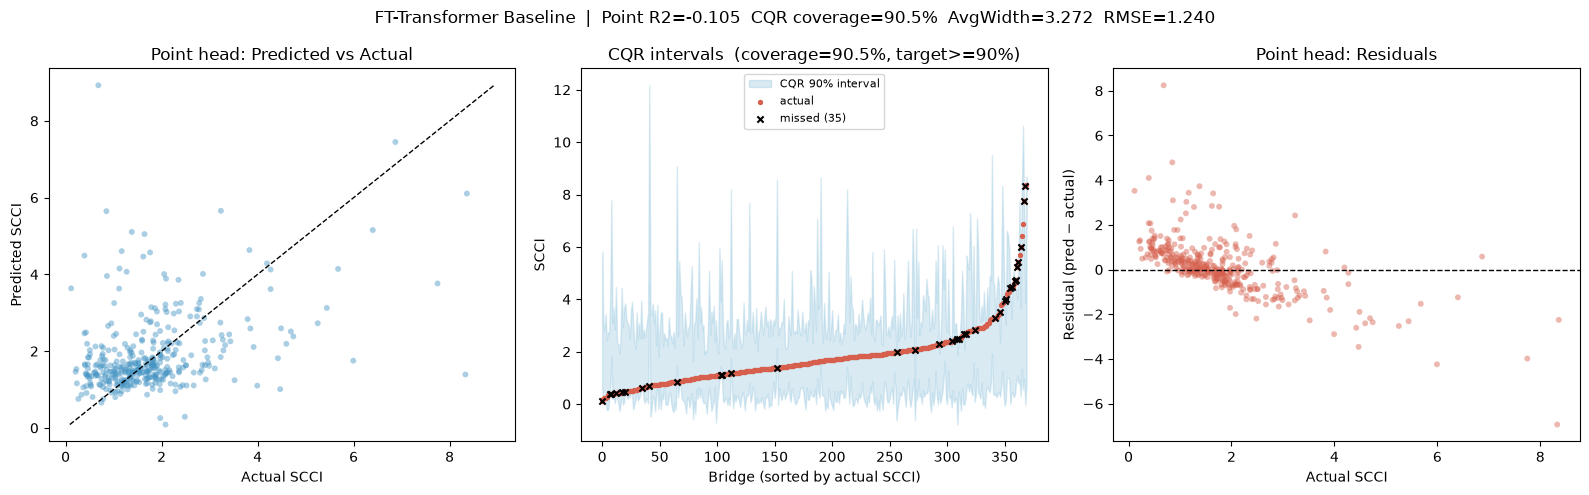

C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Subset


def collect_scci_preds(fold_idx):
    load_fold(fold_idx)
    loader = DataLoader(
        Subset(labeled_dataset, fold_states[fold_idx]['cal_idx']),
        batch_size=256, shuffle=False, pin_memory=False, num_workers=0,
    )
    q_los, q_his, pts, tgts = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            num_x, cat_x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out   = model(num_x, cat_x, alpha=ALPHA)
            valid = ~torch.isnan(y_sc)
            q_los.append((out['scci_direct']['q_lo'][valid] - Q_scci).cpu().numpy())
            q_his.append((out['scci_direct']['q_hi'][valid] + Q_scci).cpu().numpy())
            pts.append(out['scci_point'][valid].cpu().numpy())
            tgts.append(y_sc[valid].cpu().numpy())
    return (np.concatenate(q_los), np.concatenate(q_his),
            np.concatenate(pts),   np.concatenate(tgts))


all_qlo, all_qhi, all_pts, all_tgts, all_q = [], [], [], [], []
for fi in range(len(fold_states)):
    qlo, qhi, pts, tgts = collect_scci_preds(fi)
    all_qlo.append(qlo); all_qhi.append(qhi)
    all_pts.append(pts); all_tgts.append(tgts)
    all_q.append(fold_states[fi]['Q_scci'])

q_lo    = np.concatenate(all_qlo)
q_hi    = np.concatenate(all_qhi)
preds   = np.concatenate(all_pts)
targets = np.concatenate(all_tgts)
covered = (targets >= q_lo) & (targets <= q_hi)
mid     = (q_lo + q_hi) / 2

r2_pt   = r2_score(targets, preds)
r2_mid  = r2_score(targets, mid)
rmse    = np.sqrt(np.mean((preds - targets) ** 2))
cov     = covered.mean()
width   = np.mean(q_hi - q_lo)

print(f'Point R2={r2_pt:.3f}  Mid R2={r2_mid:.3f}  RMSE={rmse:.3f}')
print(f'CQR coverage={cov:.1%} (target>=90%)  AvgWidth={width:.3f}')
print(f'Per-fold Q_scci: {[round(q, 4) for q in all_q]}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'FT-Transformer Baseline  |  Point R2={r2_pt:.3f}  CQR coverage={cov:.1%}'
    f'  AvgWidth={width:.3f}  RMSE={rmse:.3f}',
    fontsize=12,
)

ax = axes[0]
ax.scatter(targets, preds, alpha=0.45, s=18, color='#4393c3', edgecolors='none')
mn, mx = min(targets.min(), preds.min()), max(targets.max(), preds.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Actual SCCI'); ax.set_ylabel('Predicted SCCI')
ax.set_title('Point head: Predicted vs Actual')

ax = axes[1]
order  = np.argsort(targets)
xs     = np.arange(len(targets))
ax.fill_between(xs, q_lo[order], q_hi[order],
                alpha=0.35, color='#92c5de', label='CQR 90% interval')
ax.scatter(xs, targets[order], s=8, color='#d6604d', zorder=3, label='actual')
missed = ~covered[order]
ax.scatter(xs[missed], targets[order][missed], s=20, color='black',
           zorder=4, marker='x', label=f'missed ({missed.sum()})')
ax.set_xlabel('Bridge (sorted by actual SCCI)'); ax.set_ylabel('SCCI')
ax.set_title(f'CQR intervals  (coverage={cov:.1%}, target>=90%)')
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(targets, preds - targets, alpha=0.45, s=18,
           color='#d6604d', edgecolors='none')
ax.axhline(0, color='k', lw=1, linestyle='--')
ax.set_xlabel('Actual SCCI'); ax.set_ylabel('Residual (pred − actual)')
ax.set_title('Point head: Residuals')

plt.tight_layout()
plt.show()
load_fold(0)

# 6. OOF Evaluation

In [7]:
from sklearn.metrics import r2_score
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

oof_pts  = np.full(len(labeled_dataset), np.nan)
oof_mids = np.full(len(labeled_dataset), np.nan)
oof_tgts = np.full(len(labeled_dataset), np.nan)

for fold_idx, fs in enumerate(fold_states):
    load_fold(fold_idx)
    cal_loader = DataLoader(Subset(labeled_dataset, fs['cal_idx']),
                            batch_size=256, shuffle=False,
                            pin_memory=False, num_workers=0)
    pts, mids, tgts, idxs = [], [], [], []
    row_ptr = 0
    with torch.no_grad():
        for batch in cal_loader:
            num_x, cat_x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out         = model(num_x, cat_x, alpha=ALPHA)
            valid       = ~torch.isnan(y_sc)
            batch_size  = num_x.size(0)
            global_idxs = fs['cal_idx'][row_ptr:row_ptr + batch_size]
            row_ptr    += batch_size
            valid_cpu   = valid.cpu().numpy()
            pts.append(out['scci_point'][valid].cpu().numpy())
            q_lo = out['scci_direct']['q_lo'][valid]
            q_hi = out['scci_direct']['q_hi'][valid]
            mids.append(((q_lo + q_hi) / 2).cpu().numpy())
            tgts.append(y_sc[valid].cpu().numpy())
            idxs.extend([global_idxs[i] for i, v in enumerate(valid_cpu) if v])

    oof_pts[idxs]  = np.concatenate(pts)
    oof_mids[idxs] = np.concatenate(mids)
    oof_tgts[idxs] = np.concatenate(tgts)

valid_mask = ~np.isnan(oof_tgts)
oof_pts    = oof_pts[valid_mask]
oof_mids   = oof_mids[valid_mask]
oof_tgts   = oof_tgts[valid_mask]

r2_pt,  rmse_pt,  mae_pt  = (r2_score(oof_tgts, oof_pts),
                              np.sqrt(np.mean((oof_pts  - oof_tgts)**2)),
                              np.mean(np.abs(oof_pts  - oof_tgts)))
r2_mid, rmse_mid, mae_mid = (r2_score(oof_tgts, oof_mids),
                              np.sqrt(np.mean((oof_mids - oof_tgts)**2)),
                              np.mean(np.abs(oof_mids - oof_tgts)))

W = 60
print()
print('=' * W)
print(f'  FT-Transformer OOF Evaluation  ({valid_mask.sum()} rows, zero leakage)')
print('=' * W)
print(f"  {'Predictor':<14}  {'R2':>10}  {'RMSE':>10}  {'MAE':>10}")
print(f"  {'-'*48}")
print(f"  {'MSE head':<14}  {r2_pt:+.4f}      {rmse_pt:.4f}      {mae_pt:.4f}")
print(f"  {'Quantile mid':<14}  {r2_mid:+.4f}      {rmse_mid:.4f}      {mae_mid:.4f}")
print()
print('  Each row predicted by the 1 fold model that never trained on it.')

load_fold(0)

C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



  FT-Transformer OOF Evaluation  (370 rows, zero leakage)
  Predictor               R2        RMSE         MAE
  ------------------------------------------------
  MSE head        -0.1055      1.2402      0.8095
  Quantile mid    -0.0866      1.2296      0.8432

  Each row predicted by the 1 fold model that never trained on it.


C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


# 7. CAP Curve — Shear-Critical Bridge Ranking

C:\Users\hengc\AppData\Local\Temp\ipykernel_26160\1899236944.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Total: 370  |  Shear-critical (SCCI<1): 82 (22.2%)


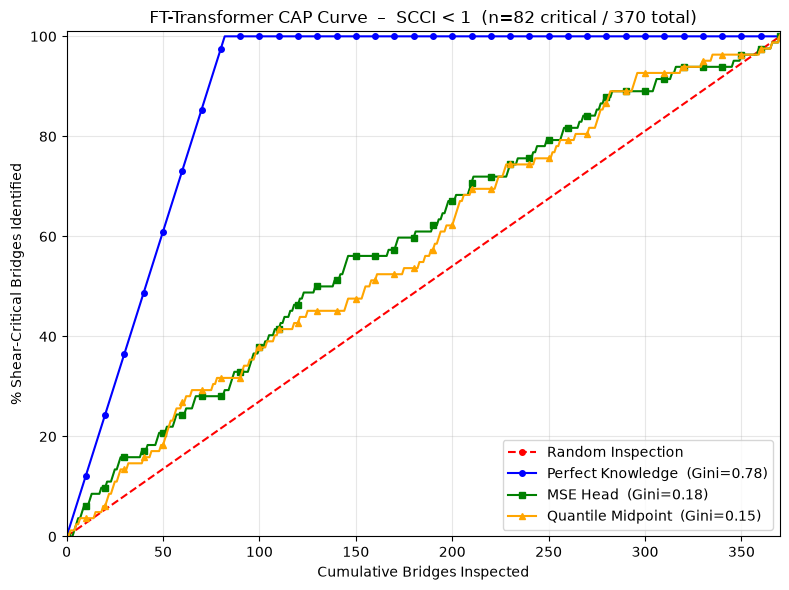

Gini coefficients:
  Perfect Knowledge : 0.7784
  MSE head          : 0.1823  (23.4% of perfect)
  Quantile midpoint : 0.1514  (19.4% of perfect)


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

SCCI_CRITICAL_THRESHOLD = 1

oof_pts  = np.full(len(labeled_dataset), np.nan)
oof_mids = np.full(len(labeled_dataset), np.nan)
oof_tgts = np.full(len(labeled_dataset), np.nan)

for fold_idx, fs in enumerate(fold_states):
    load_fold(fold_idx)
    cal_loader = DataLoader(Subset(labeled_dataset, fs['cal_idx']),
                            batch_size=256, shuffle=False,
                            pin_memory=False, num_workers=0)
    pts, mids, tgts, idxs = [], [], [], []
    row_ptr = 0
    with torch.no_grad():
        for batch in cal_loader:
            num_x, cat_x, y_sc, _ = [t.to(DEVICE) for t in batch]
            out         = model(num_x, cat_x, alpha=ALPHA)
            valid       = ~torch.isnan(y_sc)
            batch_size  = num_x.size(0)
            global_idxs = fs['cal_idx'][row_ptr:row_ptr + batch_size]
            row_ptr    += batch_size
            valid_cpu   = valid.cpu().numpy()
            pts.append(out['scci_point'][valid].cpu().numpy())
            q_lo = out['scci_direct']['q_lo'][valid]
            q_hi = out['scci_direct']['q_hi'][valid]
            mids.append(((q_lo + q_hi) / 2).cpu().numpy())
            tgts.append(y_sc[valid].cpu().numpy())
            idxs.extend([global_idxs[i] for i, v in enumerate(valid_cpu) if v])
    oof_pts[idxs]  = np.concatenate(pts)
    oof_mids[idxs] = np.concatenate(mids)
    oof_tgts[idxs] = np.concatenate(tgts)

valid_mask = ~np.isnan(oof_tgts)
pts_v   = oof_pts[valid_mask]
mids_v  = oof_mids[valid_mask]
tgts_v  = oof_tgts[valid_mask]
n_total = len(tgts_v)

is_critical = (tgts_v < SCCI_CRITICAL_THRESHOLD).astype(int)
n_critical  = is_critical.sum()
print(f'Total: {n_total}  |  Shear-critical (SCCI<{SCCI_CRITICAL_THRESHOLD}): {n_critical} ({100*n_critical/n_total:.1f}%)')


def cap_curve(scores_ascending, labels):
    order        = np.argsort(scores_ascending)
    cum_critical = np.cumsum(labels[order])
    x = np.arange(1, n_total + 1)
    y = cum_critical / n_critical * 100
    return np.concatenate([[0], x]), np.concatenate([[0], y])


def gini(x, y):
    rand_y = x / n_total * 100
    return np.trapezoid(y - rand_y, x) / np.trapezoid(100 - rand_y, x)


x_rand = np.array([0, n_total]); y_rand = np.array([0, 100])
x_perf, y_perf = cap_curve(tgts_v, is_critical)
x_pt,   y_pt   = cap_curve(pts_v,  is_critical)
x_mid,  y_mid  = cap_curve(mids_v, is_critical)

g_perf = gini(x_perf, y_perf)
g_pt   = gini(x_pt,   y_pt)
g_mid  = gini(x_mid,  y_mid)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_rand, y_rand, 'r--', marker='o', markersize=4, markevery=10,
        label='Random Inspection')
ax.plot(x_perf, y_perf, 'b-',  marker='o', markersize=4, markevery=10,
        label=f'Perfect Knowledge  (Gini={g_perf:.2f})')
ax.plot(x_pt,   y_pt,   'g-',  marker='s', markersize=4, markevery=10,
        label=f'MSE Head  (Gini={g_pt:.2f})')
ax.plot(x_mid,  y_mid,  color='orange', linestyle='-', marker='^',
        markersize=4, markevery=10,
        label=f'Quantile Midpoint  (Gini={g_mid:.2f})')
ax.set_xlabel('Cumulative Bridges Inspected')
ax.set_ylabel('% Shear-Critical Bridges Identified')
ax.set_title(
    f'FT-Transformer CAP Curve  –  SCCI < {SCCI_CRITICAL_THRESHOLD}'
    f'  (n={n_critical} critical / {n_total} total)'
)
ax.legend(loc='lower right')
ax.set_xlim(0, n_total); ax.set_ylim(0, 101)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gini coefficients:')
print(f'  Perfect Knowledge : {g_perf:.4f}')
print(f'  MSE head          : {g_pt:.4f}  ({100*g_pt/g_perf:.1f}% of perfect)')
print(f'  Quantile midpoint : {g_mid:.4f}  ({100*g_mid/g_perf:.1f}% of perfect)')

load_fold(0)